In [70]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [71]:
df = pd.read_csv("adult_with_headers.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [72]:
df.shape

(32561, 15)

In [73]:
# DataSet Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [74]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Missing Values

In [75]:
# In this dataset missing values are stored as " ?"

In [76]:
df.replace(" ?", np.nan, inplace=True)

df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

### Handle Missing Values

In [77]:
# Replace missing categorical values using the mode.
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])

In [78]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

#### Numerical Columns

In [79]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

### Standard Scaling

In [80]:
scaler = StandardScaler()
df_standard = df.copy()
df_standard[num_cols] = scaler.fit_transform(df_standard[num_cols])
df_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,-1.063611,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.148453,-0.21666,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,-1.008707,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145920,-0.21666,-2.222153,United-States,<=50K
2,-0.042642,Private,0.245079,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
3,1.057047,Private,0.425801,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
4,-0.775768,Private,1.408176,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145920,-0.21666,-0.035429,Cuba,<=50K


### Min-Max-Scaling

In [81]:
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = minmax.fit_transform(df_minmax[num_cols])
df_minmax.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


#### a. Standard Scaling (Z-score Scaling)
Preferred when:
- Data follows a normal (Gaussian) distribution.
- Algorithms such as Logistic Regression, Linear Regression, SVM, PCA, and KNN are used.
- It transforms data to have mean = 0 and standard deviation = 1, ensuring all features contribute equally to the model.
    
#### b. Min-Max Scaling
Preferred when:
- Data does not follow a normal distribution.
- Algorithms such as Neural Networks, K-Means Clustering, and Gradient Descent-based models are used.
- It scales all values to the range [0, 1], preserving the original distribution while preventing features with larger values from dominating the model.

# 2. Encoding Techniques:

#### a) One-Hot Encoding (< 5 Categories)

In [82]:
# Check unique values:
for col in df.select_dtypes(include='object').columns:
    print(col, ":", df[col].nunique())

workclass : 8
education : 16
marital_status : 7
occupation : 14
relationship : 6
race : 5
sex : 2
native_country : 41
income : 2


In [83]:
# Applying One-Hot Encoding to columns with 5 or fewer categories (sex and race):
df_ohe = pd.get_dummies(df, columns=['sex', 'race'], dtype=int)

df_ohe.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Female,sex_ Male,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,2174,0,40,United-States,<=50K,0,1,0,0,0,0,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,0,0,13,United-States,<=50K,0,1,0,0,0,0,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,0,0,40,United-States,<=50K,0,1,0,0,0,0,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,40,United-States,<=50K,0,1,0,0,1,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,0,0,40,Cuba,<=50K,1,0,0,0,1,0,0


#### (b) Label Encoding (> 5 Categories)

In [84]:
from sklearn.preprocessing import LabelEncoder

In [85]:
le = LabelEncoder()

In [86]:
label_cols = ['workclass',
              'education',
              'marital_status',
              'occupation',
              'relationship',
              'native_country',
              'income']

for col in label_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,77516,9,13,4,0,1,White,Male,2174,0,40,38,0
1,50,5,83311,9,13,2,3,0,White,Male,0,0,13,38,0
2,38,3,215646,11,9,0,5,1,White,Male,0,0,40,38,0
3,53,3,234721,1,7,2,5,0,Black,Male,0,0,40,38,0
4,28,3,338409,9,13,2,9,5,Black,Female,0,0,40,4,0


### Pros & Cons:
#### One-Hot Encoding:

Pros:
- No ordinal relationship is introduced.
- Works well for nominal categorical data.

Cons:
- Increases the number of features.
- Can make the dataset sparse when categories are many.

#### Label Encoding

Pros:
- Simple and memory efficient.
- Suitable for tree-based models like Decision Trees and Random Forest.

Cons
- Introduces an artificial order among categories.
- Not suitable for linear models when categories are nominal.

# Task 3: Feature Engineering


### Creating 2 New Features
#### Feature 1: ExperienceScore
This feature represents the ExperienceScore

- Rationale: Combines age and education level to represent an individual's potential experience and qualification.

In [87]:
df['ExperienceScore'] = df['age'] * df['education_num']

df[['age','education_num','ExperienceScore']].head()

,age,education_num,ExperienceScore
0,39,13,507
1,50,13,650
2,38,9,342
3,53,7,371
4,28,13,364


#### Feature 2: Work Efficiency
This feature represents the work Efficiency

- Rationale: Represents the number of hours worked relative to education level.

In [88]:
df['WorkEfficiency'] = df['hours_per_week'] / (df['education_num'] + 1)

df[['hours_per_week','education_num','WorkEfficiency']].head()

,hours_per_week,education_num,WorkEfficiency
0,40,13,2.857143
1,13,13,0.928571
2,40,9,4.000000
3,40,7,5.000000
4,40,13,2.857143


#### Step 1: Check Skewness
For the Adult dataset, the best skewed numerical feature is capital_gain because it is highly right-skewed (most values are 0, with a few very large values).

In [89]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].skew().sort_values(ascending=False)

capital_gain       11.953848
capital_loss        4.594629
WorkEfficiency      3.333826
fnlwgt              1.446980
income              1.212430
ExperienceScore     0.807756
relationship        0.786818
age                 0.558743
hours_per_week      0.227643
workclass           0.076469
occupation          0.000565
marital_status     -0.013508
education_num      -0.311676
education          -0.934042
native_country     -4.243158
dtype: float64

###### capital_gain has the highest positive skewness.

### Step 2: Apply Log Transformation

will Use log1p() because capital_gain contains many zeros.

In [90]:
import numpy as np

df['capital_gain_log'] = np.log1p(df['capital_gain'])

### Step 3: Visualization

In [91]:
print("Before:", df['capital_gain'].skew())
print("After :", df['capital_gain_log'].skew())

Before: 11.953847687699804
After : 3.096143524467517


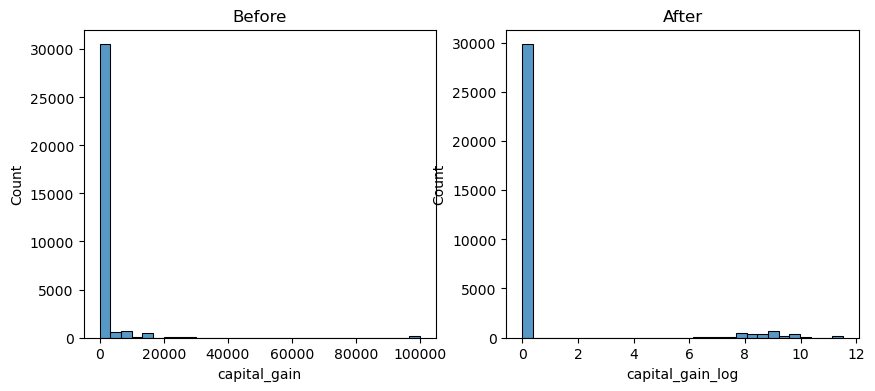

In [92]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['capital_gain'], bins=30)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(df['capital_gain_log'], bins=30)
plt.title("After")

plt.show()

- capital_gain is highly right-skewed because most values are 0, while a few values are very large.
- After applying log1p(), the distribution became more balanced, although many values remain at 0 because most people have no capital gain.
- Log transformation reduces the effect of these very large values and makes the data more balanced.
- This helps machine learning models learn better and reduces the influence of extreme values.
